### Лабораторная работа 6 (Синтезатор частот)

In [13]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

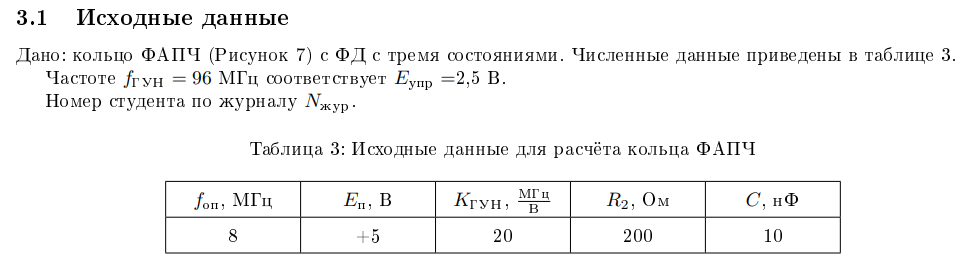
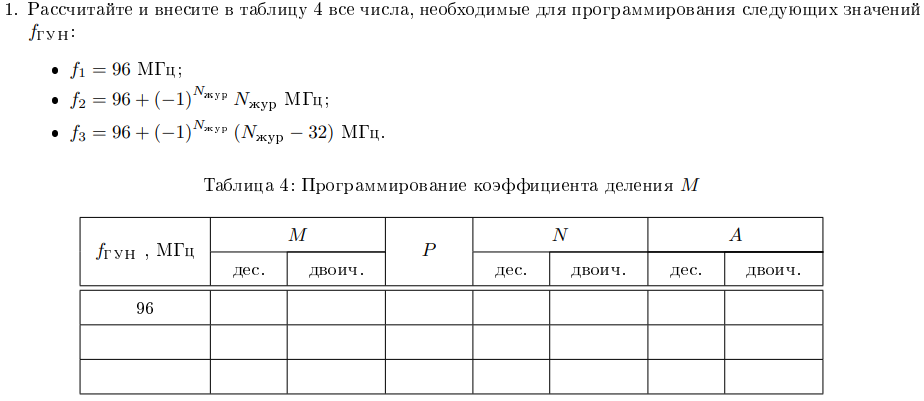

In [14]:
f_op = 8e6
E_p = 5
K_gun = 20 #(МГц/В)
R2 = 200 
C = 10e-9

f_gun1 = 96 # Мгц
f_gun2 = 96 + (-1)**15 * 15
f_gun3 = 96 + (-1)**15 * (15 - 32)

print(f'f_gun2 = {f_gun2}')
print(f'f_gun3 = {f_gun3}')


f_gun2 = 81
f_gun3 = 113


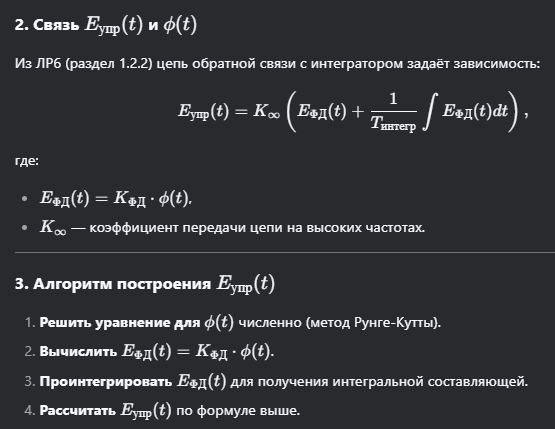

Функция cumtrapz из библиотеки SciPy в Python выполняет кумулятивное численное интегрирование методом трапеций. Она вычисляет интеграл от начала данных до каждой текущей точки, возвращая массив накопленных значений. Это полезно, когда нужно получить "историю" интеграла нарастающим итогом, а не только итоговое значение.

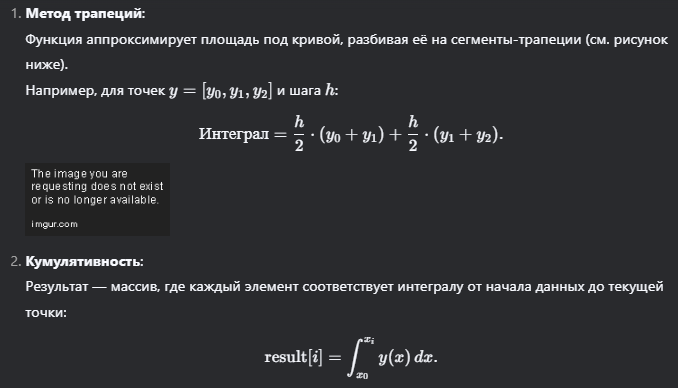

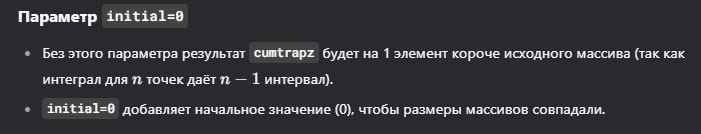

Т_фапч = 5.649999999999999e-05
Т_интегр = 2e-06
Сигма = 28.249999999999996
Кфд = 0.7957747154594768
Кinf = 0.02


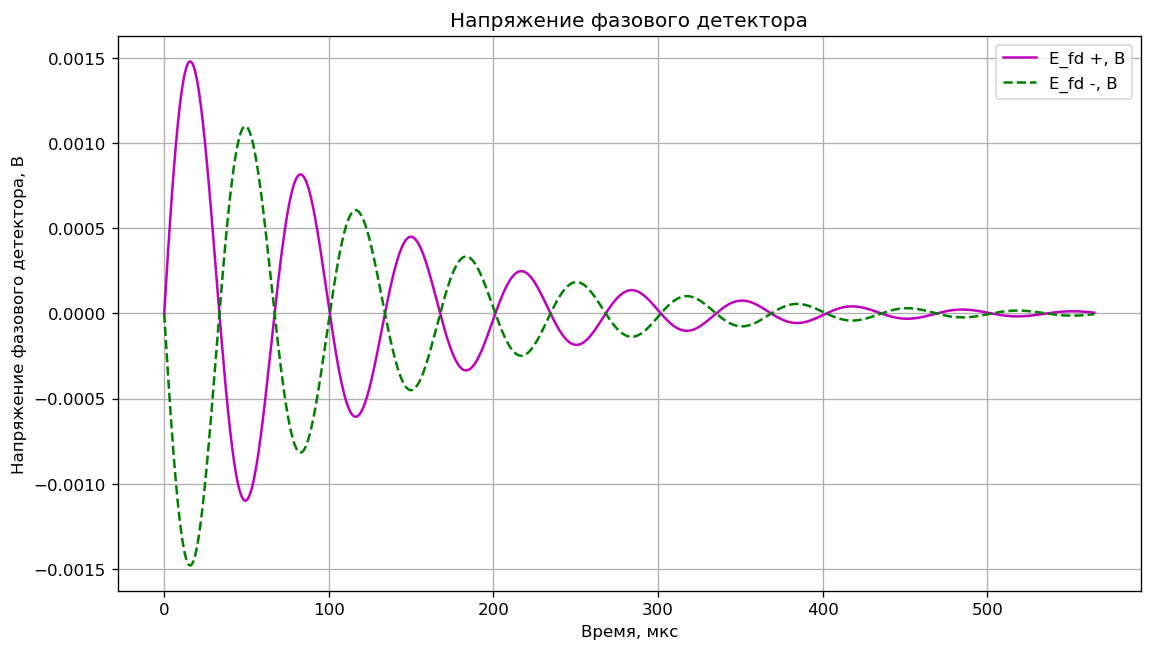

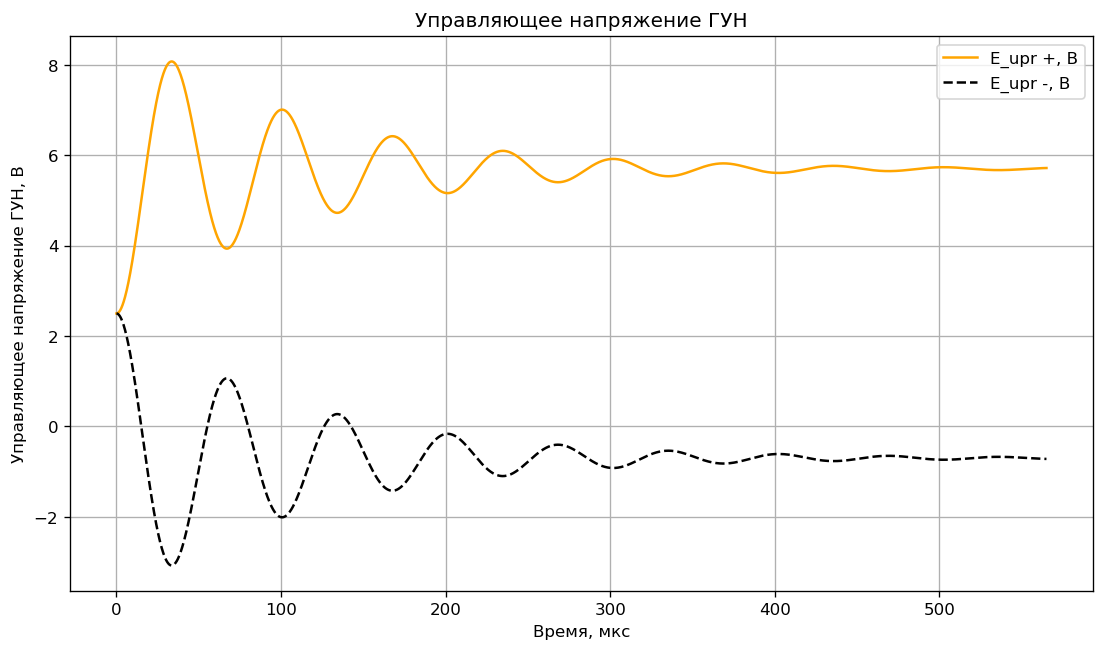

In [15]:
from scipy.integrate import solve_ivp, cumtrapz

# Параметры системы (пример)
# Параметры системы
R1 = 10000
R2 = 200
E_p = 5

K_fd = E_p / (2 * np.pi)

# Расчет T_integr
T_integr = 10e-9 * 200  # 2e-6 сек

T_fapch = 113 / (2 * np.pi * 20e6 * (R2 / R1) * K_fd)

K_infty = R2 / R1           # Коэффициент передачи цепи ОС

# Коэффициент sigma
sigma = T_fapch / T_integr


# Начальные условия (после скачка M)
phi0 = 0           # Начальная разность фаз
dphi0_1 = 64*np.pi * T_fapch              # Начальная производная
dphi0_2 = - 64*np.pi * T_fapch

# dphi0_1 = 1e6 * 64*np.pi * T_fapch              # Начальная производная
# dphi0_2 = - 1e6 * 64*np.pi * T_fapch

# Система уравнений для φ(t)
def dydx(x, y):
    y1, y2 = y
    dy1dx = y2
    dy2dx = -y2 - sigma * y1
    return [dy1dx, dy2dx]

# Численное решение
x_span = (0, 10)         # Безразмерное время x
x_eval = np.linspace(0, 10, 4000)

sol_1 = solve_ivp(dydx, x_span, [phi0, dphi0_1], t_eval=x_eval, method='RK45')
sol_2 = solve_ivp(dydx, x_span, [phi0, dphi0_2], t_eval=x_eval, method='RK45')

# Вычисление E_ФД(t)
phi_1 = sol_1.y[0]
E_fd_1 = K_fd * phi_1

phi_2 = sol_2.y[0]
E_fd_2 = K_fd * phi_2


# Интеграл E_ФД(t)
integral_E_fd_1 = cumtrapz(E_fd_1, x=x_eval, initial=0)
integral_E_fd_2 = cumtrapz(E_fd_2, x=x_eval, initial=0)

# Вычисление E_упр(t)
E_upr_1_1_1 = K_infty * (E_fd_1 + (1 / T_integr) * integral_E_fd_1)
E_upr_2 = K_infty * (E_fd_2 + (1 / T_integr) * integral_E_fd_2)

print(f"Т_фапч = {T_fapch}")
print(f"Т_интегр = {T_integr}")
print(f"Сигма = {sigma}")
print(f"Кфд = {K_fd}")
print(f"Кinf = {K_infty}")


# График E_ФД(t)

# plt.figure(figsize=(11, 6), dpi=120)
# plt.plot(sol_1.t * T_fapch*10**6, phi_1, color='m', label="phi +, radian")
# plt.plot(sol_2.t * T_fapch*10**6, phi_2,linestyle = '--', color='g', label="phi -, radian")
# plt.xlabel('Время, мкс')
# plt.ylabel("phi, radian")
# plt.title('Переходной процесс phi')
# plt.grid(True)
# plt.legend()

plt.figure(figsize=(11, 6), dpi=120)
plt.plot(sol_1.t * T_fapch*10**6, E_fd_1, color='m', label="E_fd +, В")
plt.plot(sol_2.t * T_fapch*10**6, E_fd_2, color='g', linestyle = '--', label="E_fd -, В")
plt.xlabel('Время, мкс')
plt.ylabel("Напряжение фазового детектора, В")
plt.title('Напряжение фазового детектора')
plt.grid(True)
plt.legend()

# График E_упр(t)
plt.figure(figsize=(11, 6), dpi=120)
plt.plot(sol_1.t * T_fapch*10**6, 2.5 + E_upr_1_1_1, color='orange', label="E_upr +, В")
plt.plot(sol_2.t * T_fapch*10**6, 2.5 + E_upr_2, linestyle = '--', color='black', label="E_upr -, В")
plt.xlabel('Время, мкс')
plt.ylabel("Управляющее напряжение ГУН, В")
plt.title('Управляющее напряжение ГУН')
plt.grid(True)
plt.legend()
plt.show()

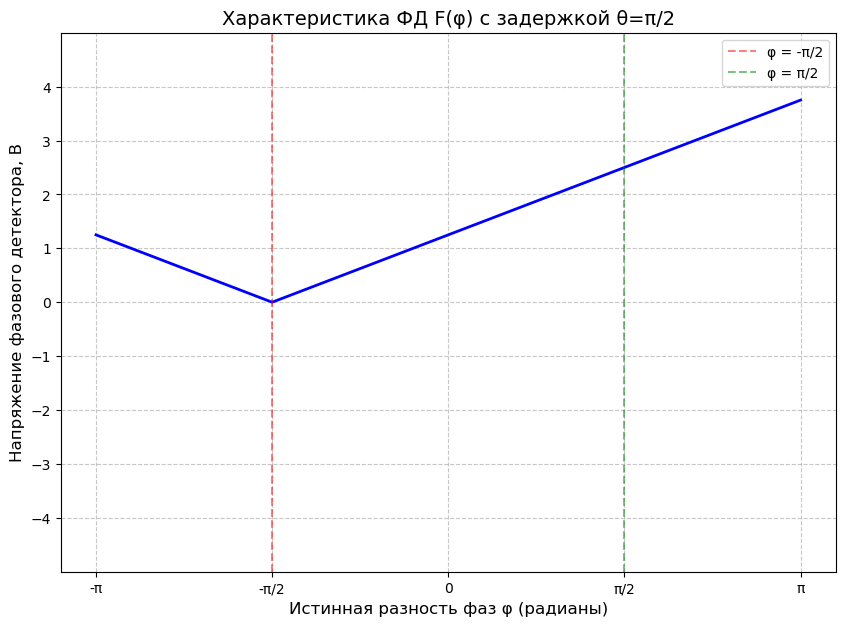

In [16]:

# Параметры
E_n = 5                   # Напряжение питания (В)
theta = np.pi/2           # Задержка (π/2 рад)
K_ph = E_n / (2 * np.pi)  # Крутизна (В/рад)
phi = np.linspace(-np.pi, np.pi, 1000)  # Истинная разность фаз

# Расчёт F(φ) с учётом задержки и насыщения
F_phi = K_ph * (phi + theta)  # Линейная часть
# F_phi = np.clip(F_phi, -E_n/2, E_n/2)  # Насыщение при ±2.5 В

# Построение графика
plt.figure(figsize=(10, 7))
plt.plot(phi, abs(F_phi), linewidth=2, color='b')
plt.title('Характеристика ФД F(φ) с задержкой θ=π/2', fontsize=14)
plt.xlabel('Истинная разность фаз φ (радианы)', fontsize=12)
plt.ylabel('Напряжение фазового детектора, В', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Вертикальные линии для наглядности
plt.axvline(-np.pi/2, color='r', linestyle='--', alpha=0.5, label='φ = -π/2')
plt.axvline(np.pi/2, color='g', linestyle='--', alpha=0.5, label='φ = π/2')
plt.legend()

# Подписи осей
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           ['-π', '-π/2', '0', 'π/2', 'π'])
plt.yticks(np.arange(-4, 5))
plt.ylim(-5, 5)
plt.show()

### Выполнение работы

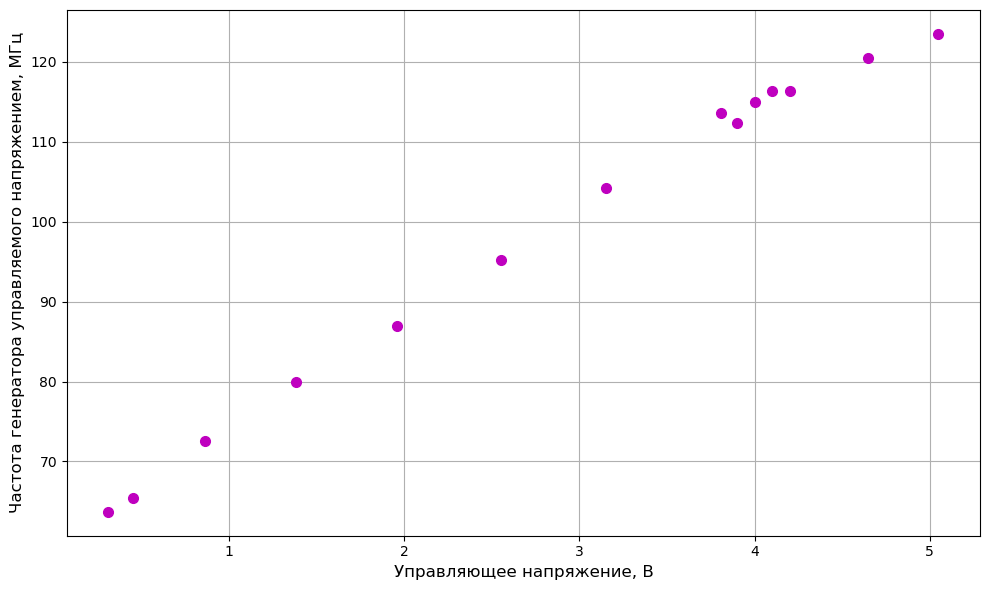

In [17]:
# Построение характеристики управления частотой ГУН fгун(Еупр)

# Данные
Еupr = [0.31,	0.45,	0.86,	1.38,	1.96,	2.55,	3.15,	3.81,	3.9,	4,	4.1, 4.2,	4.65,	5.05]
fgun =[63.7,	65.4,	72.5,	80,	87,	95.2,	104.2,	113.6,	112.4,	115	,116.3, 116.3,	120.5,	123.5]

# Создание фигуры с двумя субплотами
plt.figure(figsize=(10, 6))

# График для математических ожиданий
plt.plot(Еupr, fgun, marker='o', linestyle='none',ms = 7, color='m')
plt.xlabel('Управляющее напряжение, В', fontsize=12)
plt.ylabel('Частота генератора управляемого напряжением, МГц', fontsize=12)
plt.grid(True)

# Настройка отступов и отображение
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

data_1 = pd.read_csv('scope_csv_122_0.csv', index_col= False) # R -положение 2, С - положение 1 (апериод)
data_2 = pd.read_csv('scope_csv_122_1.csv', index_col= False) # R -положение 5, С - положение 1 (коле. затух.)

In [19]:
data_1.head()

,Time [s],CH2 [V]
0,8.000000e-07,1.7
1,8.000000e-07,1.7
2,8.000000e-07,1.7
3,8.000000e-07,1.7
4,8.000000e-07,1.7


In [20]:
data_2.head()

,Time [s],CH2 [V]
0,8.000000e-07,1.7
1,8.000000e-07,1.7
2,8.000000e-07,1.7
3,8.000000e-07,1.7
4,8.000000e-07,1.7


In [21]:
# Параметры системы R -положение 2, С - положение 1
Kgun = 13.9e6
С_1 = 100e-9
E_p = 5
K_fd = E_p / (2 * np.pi)

R_1_1 = 10000
R_2_1 = 1800

# Расчет T_integr
T_integr_1 = С_1 * R_2_1 

T_fapch_1 = 91 / (2 * np.pi * Kgun * (R_2_1 / R_1_1) * K_fd)

K_infty_1 = R_2_1 / R_1_1  

# Коэффициент sigma
sigma_1 = T_fapch_1 / T_integr_1

tau_1 = T_integr_1 / T_fapch_1

# Параметры системы R -положение 5, С - положение 1

R_1_2 = 10000
R_2_2 = 1500

# Расчет T_integr
T_integr_2 = С_1 * R_2_2

T_fapch_2 = 91 / (2 * np.pi * Kgun * (R_2_2 / R_1_2) * K_fd)


K_infty_2 = R_2_2 / R_1_2  

# Коэффициент sigma
sigma_2 = T_fapch_2 / T_integr_2

print(f'Tfapch1 = {T_fapch_1}')

print(f'Tfapch2 = {T_fapch_2}')

Tfapch1 = 7.274180655475619e-06
Tfapch2 = 8.729016786570744e-06


In [22]:
# Начальные условия (после скачка M)
phi0 = 0           # Начальная разность фаз
dphi0_1 = 105*np.pi * T_fapch_1         # Начальная производная
dphi0_2 = - 105*np.pi * T_fapch_1 

# Система уравнений для φ(t)
def dydx(x, y):
    y1, y2 = y
    dy1dx = y2
    dy2dx = (-y2 - (sigma - 4) * y1) / 0.4
    return [dy1dx, dy2dx]

# Численное решение
x_span = (0, 15)         # Безразмерное время x
x_eval = np.linspace(0, 15, 4000)

sol_1 = solve_ivp(dydx, x_span, [phi0, dphi0_1], t_eval=x_eval, method='RK45')
sol_2 = solve_ivp(dydx, x_span, [phi0, dphi0_2], t_eval=x_eval, method='RK45')

# Вычисление E_ФД(t)
phi_1 = sol_1.y[0]
E_fd_1 = K_fd * phi_1

phi_2 = sol_2.y[0]
E_fd_2 = K_fd * phi_2


# Интеграл E_ФД(t)
integral_E_fd_1 = cumtrapz(E_fd_1, x=x_eval, initial=0)
integral_E_fd_2 = cumtrapz(E_fd_2, x=x_eval, initial=0)

# Вычисление E_упр(t)
E_upr_1_teor = (K_infty - 0.01) * (E_fd_1 + (1 / (T_integr + 1e-6)) * integral_E_fd_1)
E_upr_2 = (K_infty - 0.008) * (E_fd_2 + (1 / (T_integr + 1e-6)) * integral_E_fd_2)

print(f"Т_фапч = {T_fapch}")
print(f"Т_интегр = {T_integr}")
print(f"Сигма = {sigma}")
print(f"Кфд = {K_fd}")
print(f"Кinf = {K_infty}")


Т_фапч = 5.649999999999999e-05
Т_интегр = 2e-06
Сигма = 28.249999999999996
Кфд = 0.7957747154594768
Кinf = 0.02


In [23]:
# Начальные условия (после скачка M)
phi0 = 0           # Начальная разность фаз
dphi0_1 = 58*np.pi * T_fapch_2        # Начальная производная
dphi0_2 = - 58*np.pi * T_fapch_2 

# Система уравнений для φ(t)
def dydx(x, y):
    y1, y2 = y
    dy1dx = y2
    dy2dx = -y2 - (sigma) * y1
    return [dy1dx, dy2dx]

# Численное решение
x_span = (0, 100)         # Безразмерное время x
x_eval = np.linspace(0, 100, 4000)

sol_1 = solve_ivp(dydx, x_span, [phi0, dphi0_1], t_eval=x_eval, method='RK45')
sol_2 = solve_ivp(dydx, x_span, [phi0, dphi0_2], t_eval=x_eval, method='RK45')

# Вычисление E_ФД(t)
phi_1 = sol_1.y[0]
E_fd_1_teor = K_fd * phi_1

phi_2 = sol_2.y[0]
E_fd_2 = K_fd * phi_2


# Интеграл E_ФД(t)
integral_E_fd_1 = cumtrapz(E_fd_1, x=x_eval, initial=0)
integral_E_fd_2 = cumtrapz(E_fd_2, x=x_eval, initial=0)

# Вычисление E_упр(t)
E_upr_2_teor = (K_infty - 0.01) * (E_fd_1 + (1 / (T_integr + 1e-6)) * integral_E_fd_1)
E_upr_2 = (K_infty - 0.008) * (E_fd_2 + (1 / (T_integr + 1e-6)) * integral_E_fd_2)

print(f"Т_фапч = {T_fapch}")
print(f"Т_интегр = {T_integr}")
print(f"Сигма = {sigma}")
print(f"Кфд = {K_fd}")
print(f"Кinf = {K_infty}")

Т_фапч = 5.649999999999999e-05
Т_интегр = 2e-06
Сигма = 28.249999999999996
Кфд = 0.7957747154594768
Кinf = 0.02


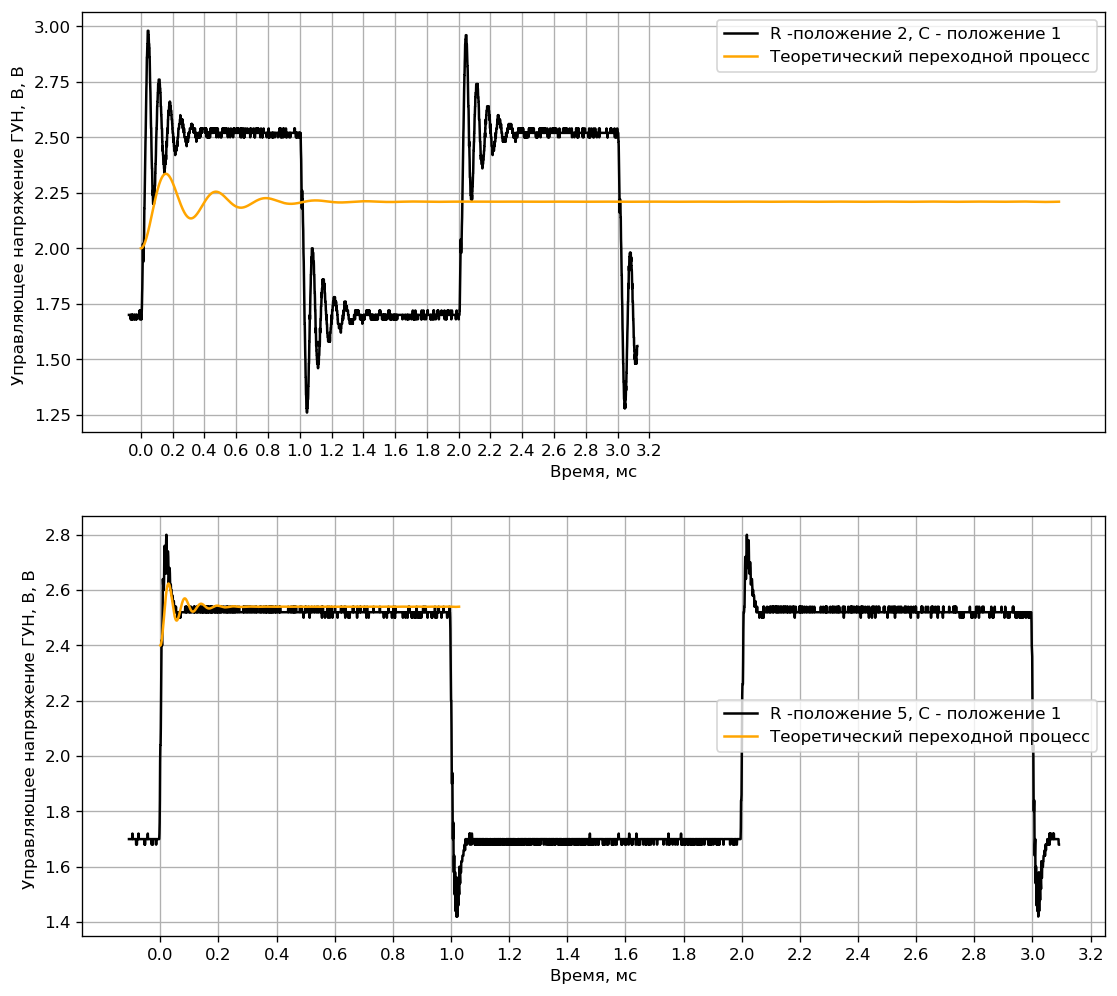

In [24]:
discrete_time_1 = 8.000000e-07 # значение дискрета по времени, взятое из таблицы csv

# Создание вектора времени
time_1 = np.arange(0, 4000 * discrete_time_1, discrete_time_1)
time_ms_1 = time_1 * 1e3 # Перевод времени в миллисекунды (умножаем на 10^3)

E_upr_1_eksp = data_1.iloc[0:4001]['CH2 [V]']
E_upr_2_eksp = data_2.iloc[0:4001]['CH2 [V]']

new_xticks_1 = np.arange(0, 3.4, 0.2)  # Задаем метки от 0 до 42 мкс с шагом 2 мкс

# Построение графиков
plt.figure(figsize=(11, 10), dpi=120)
# Осциллограмма для CH1
plt.subplot(2, 1, 1)
plt.plot(time_ms_1 - 0.075, E_upr_1_eksp, label='R -положение 2, С - положение 1', color='black')
plt.plot(sol_1.t * T_fapch_1*10**3.9, 2 + (E_upr_1_teor * 2), color='orange', label="Теоретический переходной процесс")
plt.xlabel('Время, мс')
plt.ylabel('Управляющее напряжение ГУН, В, В ')
plt.grid(True)
plt.xticks(new_xticks_1)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time_ms_1 - 0.108, E_upr_2_eksp, label='R -положение 5, С - положение 1', color='black')
plt.plot(sol_1.t * T_fapch_1*10**3.15, 2.4 + (E_upr_2_teor * 0.2), color='orange', label="Теоретический переходной процесс")
plt.xlabel('Время, мс')
plt.ylabel('Управляющее напряжение ГУН, В, В ')
plt.grid(True)
plt.xticks(new_xticks_1)
plt.legend()
plt.show()